In [34]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.datasets import make_circles

device = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cpu")
)
# device = "cpu"
# if torch.cuda.is_available():
#   device = "cuda"
# elif torch.backends.mps.is_available():
#   device = "mps"


In [71]:
# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples, noise=0.03, random_state=42)

len(X), len(y)

(1000, 1000)

In [72]:
print(f"First 5 samples of X: {X[:5]}")
print(f"First 5 samples of y: {y[:5]}")

First 5 samples of X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y: [1 1 1 1 0]


In [73]:
# Make Dataframe of circle data
import pandas as pd

circles =  pd.DataFrame({"X1": X[:, 0],
                         "X2": X[:, 1],
                         "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [74]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

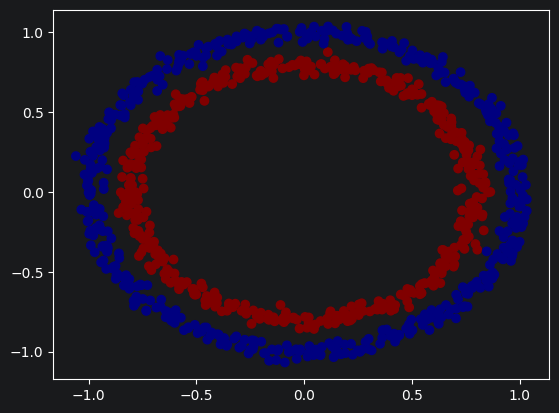

In [75]:
# Visualize Visualize Visualize
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=mpl.colormaps["jet"],)

In [40]:
# 1.1 Check input and output shape
X.shape, y.shape

((1000, 2), (1000,))

In [41]:
# View the first example of features as labels
X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


In [42]:
# 1.2 Turn data into Tensors and create train and test split
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [43]:
# split data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [44]:
# 2. Building a model
# Classify blue and red dots

# Create model
class CircleModelV0(nn.Module):
    def __init__(self):
        super(CircleModelV0, self).__init__()
        # Create linear layers capable of handling input shapes
        self.layer_1 = nn.Linear(2, 5) # Takes in 2 and upscales to 5 features
        self.layer_2 = nn.Linear(5, 1) # Takes in 5 from previous layer and outputs single feature (shape of y)

    def forward(self, x):
        """
        Define forward that outlines the forward pass
        """
        return self.layer_2(self.layer_1(x)) # x -> layer_1 -> layer_2 -> output

# Instantiate model and send to target device
model_0 = CircleModelV0().to(device)
model_0


CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [45]:
# Let's replicate the model using nn.Sequential

model_0 = nn.Sequential(
    nn.Linear(2, 5),
    nn.Linear(5, 1),
).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [46]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]], device='mps:0')),
             ('0.bias',
              tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370], device='mps:0')),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]], device='mps:0')),
             ('1.bias', tensor([-0.1213], device='mps:0'))])

In [47]:
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
print(f"Length of untrained predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"First 10 predictions:\n{untrained_preds[:10]}\n")
print(f"First 10 labels:\n{y_test[:10]}\n")

Length of untrained predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])
First 10 predictions:
tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967],
        [ 0.2968],
        [ 0.1405],
        [ 0.2178],
        [ 0.0805],
        [-0.0284]], device='mps:0')

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])



# 2.1 Setup loss function and optimizer
Which loss function or optimizer works for our problem

For classification problems: binary cross entropy, categorical cross entropy

We're going to use `torch.nn.BCEWithLogitsLoss()`

In [48]:
loss_fn = nn.BCEWithLogitsLoss() # sigmoid activation function built in

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

# Calculate accuracy - out of 100 examples, what percentage does our model get right?
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

# 3. Train model
To train our model, we're going to need to build a training loop
1. Forward pass
2. Calculate loss
3. Optimizer zero grad
4. Loss backward (backpropogation)
5. Optimizer step (gradient descent)

# 3.1 Going from raw logits -> prediction probabilities -> prediction labels
Our model outputs are going to be raw **logits**

We can convert these logits into prediction pobabilities by passing them to some kind of activation function (e.g. sigmoid for binary crossentropy and softmax for multiclass classfication).

Then we can convert our model's predictions probabilities to **prediction labels** by either rounding them or taking the `argmax()`.

In [49]:
# View first 5 outputs of the forward pass on the test data
y_logits = model_0(X_test.to(device))[:5]
print(y_logits)

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]], device='mps:0', grad_fn=<SliceBackward0>)


In [50]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [51]:
# Use sigmoid activation function on our model logits to turn them into prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
print(y_pred_probs)

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]], device='mps:0', grad_fn=<SigmoidBackward0>)


In [52]:
# For our prediction probabilities, we need to perform a range-style rounding on them:
# y_pred_prods >= 0.5 y = 1 (Class 1)
# y_pred_probs < 0.5 y = 0 (Class 0)

# Find the predicted labels from the predicted probabilities
y_preds = torch.round(y_pred_probs)

# In full
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))
print(y_pred_labels.squeeze())

tensor([True, True, True, True, True], device='mps:0')
tensor([0., 0., 1., 0., 1.], device='mps:0', grad_fn=<SqueezeBackward0>)


In [53]:
# 3.2 Building Training and Testing loop
torch.manual_seed(42)
torch.mps.manual_seed(42)

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
epochs = 1000
for epoch in range(epochs):
    model_0.train()

    # Forward pass
    y_pred_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_pred_logits)) # turn logits -> pred probs -> pred labels

    # Calculate loss/accuracy
    loss = loss_fn(y_pred_logits, y_train)
    acc = accuracy_fn(y_train, y_pred)

    # optimizer zero grad
    optimizer.zero_grad()

    # Loss backward (back propagation)
    loss.backward()

    # Optimizer step (gradient descent)
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate test loss/acc
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)


    if epoch % 10 == 0:
        print(f"Epoch: {epoch}, | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")


Epoch: 0, | Loss: 0.69796, Accuracy: 51.88% | Test Loss: 0.69440, Test Accuracy: 58.00%
Epoch: 10, | Loss: 0.69590, Accuracy: 51.25% | Test Loss: 0.69305, Test Accuracy: 53.00%
Epoch: 20, | Loss: 0.69490, Accuracy: 51.62% | Test Loss: 0.69254, Test Accuracy: 49.50%
Epoch: 30, | Loss: 0.69435, Accuracy: 51.12% | Test Loss: 0.69236, Test Accuracy: 49.50%
Epoch: 40, | Loss: 0.69401, Accuracy: 50.88% | Test Loss: 0.69232, Test Accuracy: 51.00%
Epoch: 50, | Loss: 0.69378, Accuracy: 50.25% | Test Loss: 0.69234, Test Accuracy: 50.00%
Epoch: 60, | Loss: 0.69362, Accuracy: 50.00% | Test Loss: 0.69239, Test Accuracy: 51.50%
Epoch: 70, | Loss: 0.69351, Accuracy: 50.25% | Test Loss: 0.69246, Test Accuracy: 51.00%
Epoch: 80, | Loss: 0.69342, Accuracy: 49.88% | Test Loss: 0.69254, Test Accuracy: 50.00%
Epoch: 90, | Loss: 0.69336, Accuracy: 49.88% | Test Loss: 0.69262, Test Accuracy: 53.00%
Epoch: 100, | Loss: 0.69331, Accuracy: 49.25% | Test Loss: 0.69271, Test Accuracy: 53.00%
Epoch: 110, | Loss: 0

# 4. Make predictions and evaluate model
From the metrics it looks like our model isn't learning anything...

So to inspect it let's make some predictions and make them visual



In [54]:
import requests
from pathlib import Path

# Download helper functions (if it's not already downloaded)
if Path("helper_functions.py").exists():
    print("helper_functions.py already exists, skipping")
else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping


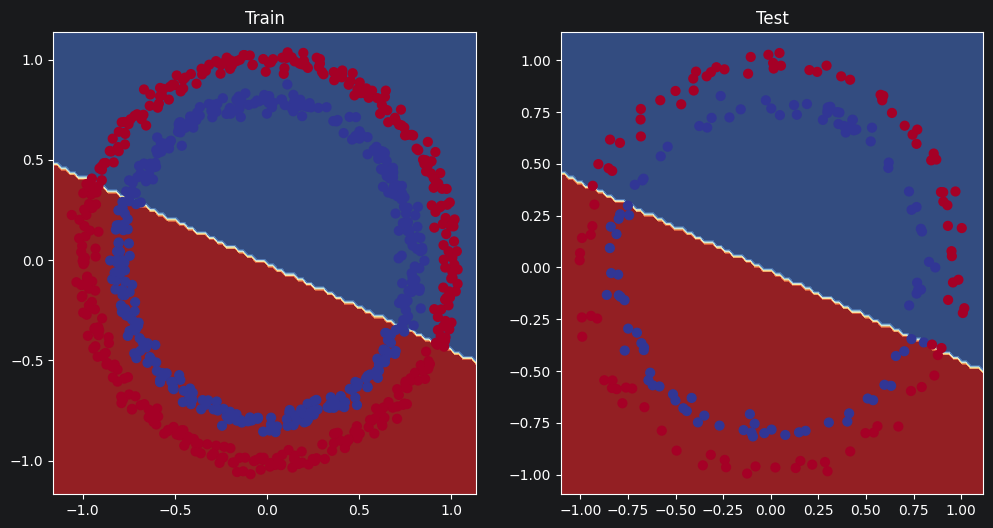

In [55]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)


# Improving a model

* Add more layers - give the model more chances to learn about patterns in the data
* Add more hidden units - go from 5 hidden units to 10 hidden units
* Fit for longer
* Changing the activation functions
* Change the learning rate
* Change the loss function

These options are all from a model's perspective not with altering the data

In [56]:
# Let's try and improve our model by adding more hidden units 5 -> 10
# Increase hidden layers 2 -> 3
# Epochs 100 -> 1000

class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(2, 10)
        self.layer_2 = nn.Linear(10, 10)
        self.layer_3 = nn.Linear(10, 1)

    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [57]:
# Create loss function
loss_fn = nn.BCEWithLogitsLoss()
# Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)
# Write training and eval loop for Model 1

torch.manual_seed(42)
torch.mps.manual_seed(42)

# Put data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs = 1000
for epoch in range(epochs):
    model_1.train()

    # Forward pass
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # Calculate loss
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_pred)

    # Optimizer zero grad
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    # Testing
    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")




Epoch: 0 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261, Test Accuracy: 51.00%
Epoch: 100 | Loss: 0.69305 | Accuracy: 50.38% | Test Loss: 0.69379, Test Accuracy: 48.00%
Epoch: 200 | Loss: 0.69299 | Accuracy: 51.12% | Test Loss: 0.69437, Test Accuracy: 46.00%
Epoch: 300 | Loss: 0.69298 | Accuracy: 51.62% | Test Loss: 0.69458, Test Accuracy: 45.00%
Epoch: 400 | Loss: 0.69298 | Accuracy: 51.12% | Test Loss: 0.69465, Test Accuracy: 46.00%
Epoch: 500 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69467, Test Accuracy: 46.00%
Epoch: 600 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468, Test Accuracy: 46.00%
Epoch: 700 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468, Test Accuracy: 46.00%
Epoch: 800 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468, Test Accuracy: 46.00%
Epoch: 900 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468, Test Accuracy: 46.00%


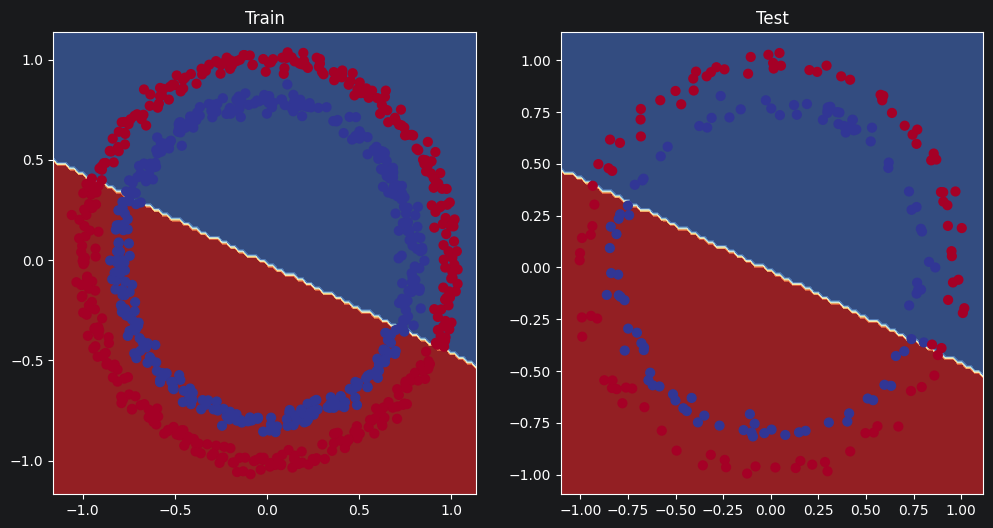

In [58]:
# Plot decision boundary
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

In [59]:
# Set up plot helper
def plot_predictions(
    train_data,
    train_labels,
    test_data,
    test_labels,
    predictions=None,
):
    """
    Plots training data, test data and compares predictions
    :return:
    :rtype:
    """
    plt.figure(figsize=[10, 7])

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="blue", s=4, label="training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="green", s=4, label="testing data")

    # Are there predictions
    if predictions is not None:
        # Plot predictions
        plt.scatter(test_data, predictions, c="red", s=4, label="predictions")

    # Show legend
    plt.legend(prop={"size": 14})
    plt.show()

# 5.1 Can our model learn anything - Linear data

One way to troubleshoot a larger problem is to test out a smaller problem



100


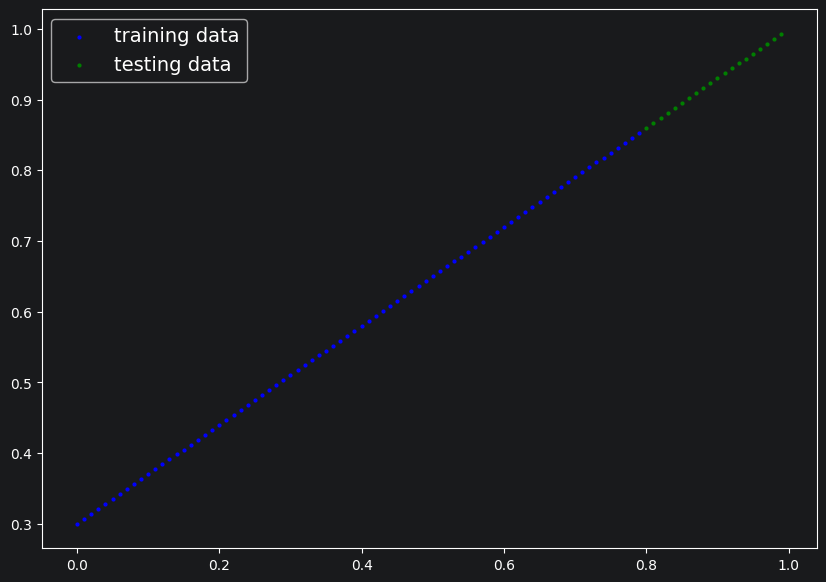

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [60]:
# Create some data
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias

# Check data
print(len(X_regression))

train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

plot_predictions(X_train_regression, y_train_regression, X_test_regression, y_test_regression)

model_1

In [61]:
# Adjusting model_1 to fit a straight line
# Same architecture as model_1 (but using nn.Sequential())

model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1),
).to(device)
model_2


Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [62]:
# Create loss function
loss_fn = nn.L1Loss()
# Create optimizer
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)
# Write training and eval loop for Model 1

torch.manual_seed(42)
torch.mps.manual_seed(42)
torch.cuda.manual_seed(42)

# Put data on target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

epochs = 1000
for epoch in range(epochs):
  y_pred = model_2(X_train_regression)
  loss = loss_fn(y_pred, y_train_regression)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_2.eval()
  with torch.inference_mode():
    test_pred = model_2(X_test_regression)
    test_loss = loss_fn(test_pred, y_test_regression)

  if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.75986 | Test Loss: 0.91103
Epoch: 100 | Loss: 0.02858 | Test Loss: 0.00081
Epoch: 200 | Loss: 0.02533 | Test Loss: 0.00209
Epoch: 300 | Loss: 0.02137 | Test Loss: 0.00305
Epoch: 400 | Loss: 0.01964 | Test Loss: 0.00341
Epoch: 500 | Loss: 0.01940 | Test Loss: 0.00387
Epoch: 600 | Loss: 0.01903 | Test Loss: 0.00379
Epoch: 700 | Loss: 0.01878 | Test Loss: 0.00381
Epoch: 800 | Loss: 0.01840 | Test Loss: 0.00329
Epoch: 900 | Loss: 0.01798 | Test Loss: 0.00360


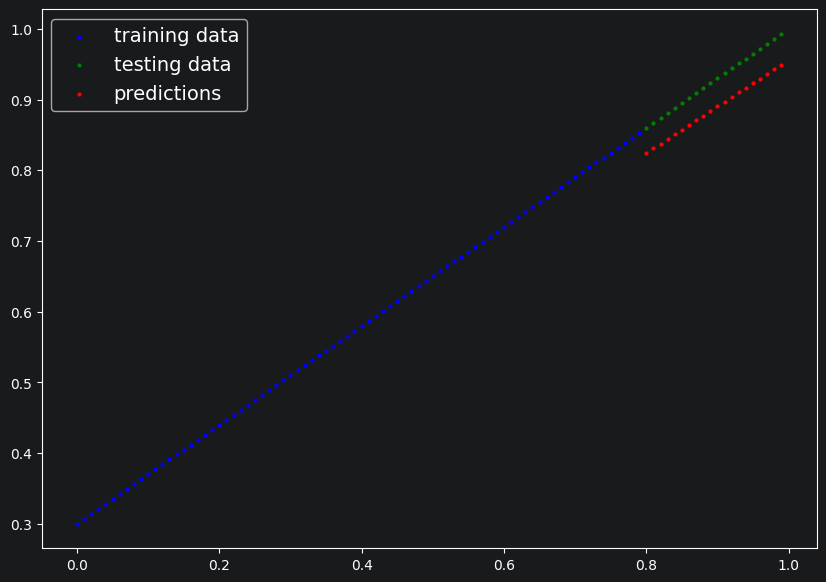

In [63]:
with torch.inference_mode():
    y_preds = model_2(X_test_regression)

plot_predictions(X_train_regression.cpu(), y_train_regression.cpu(), X_test_regression.cpu(), y_test_regression.cpu(), predictions=y_preds.cpu())

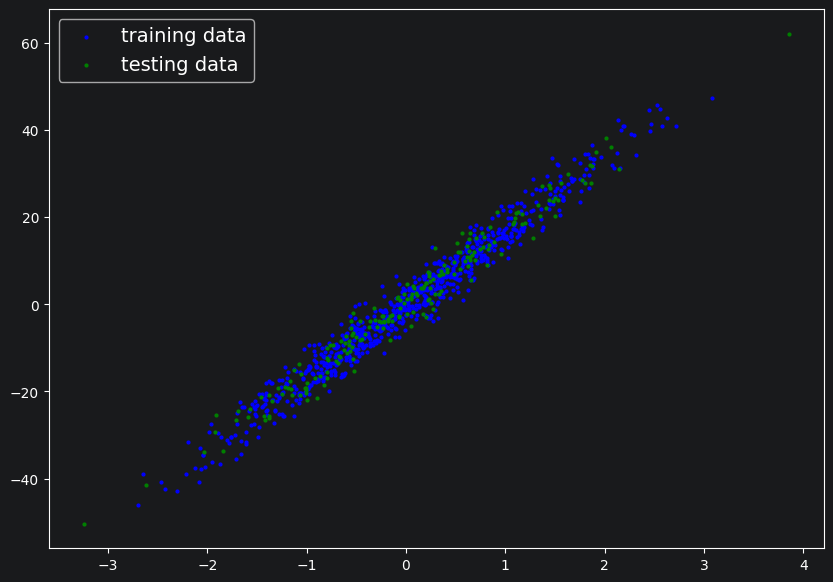

In [64]:
from sklearn.datasets import make_regression

# Generate Linear dataset
X, y = make_regression(n_samples=1000, n_features=1, noise=3, random_state=42)

# Training split
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

plot_predictions(X_train, y_train, X_test, y_test)

In [65]:
# Create loss function
loss_fn = nn.L1Loss()
# Create optimizer
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)
# Write training and eval loop for Model 1

torch.manual_seed(42)
torch.mps.manual_seed(42)
torch.cuda.manual_seed(42)

# Put data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
model_2.to(device)
epochs = 2000
for epoch in range(epochs):
  y_pred = model_2(X_train).squeeze()
  loss = loss_fn(y_pred, y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_2.eval()
  with torch.inference_mode():
    test_pred = model_2(X_test)
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

Epoch: 0 | Loss: 12.70395 | Test Loss: 13.39948


/Users/eric.musliner/Documents/dev/pytorch/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([200])) that is different to the input size (torch.Size([200, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Epoch: 100 | Loss: 2.40470 | Test Loss: 18.77909
Epoch: 200 | Loss: 2.40468 | Test Loss: 18.77229
Epoch: 300 | Loss: 2.40468 | Test Loss: 18.77178
Epoch: 400 | Loss: 2.40468 | Test Loss: 18.77168
Epoch: 500 | Loss: 2.40468 | Test Loss: 18.77198
Epoch: 600 | Loss: 2.40468 | Test Loss: 18.77188
Epoch: 700 | Loss: 2.40468 | Test Loss: 18.77178
Epoch: 800 | Loss: 2.40468 | Test Loss: 18.77168
Epoch: 900 | Loss: 2.40468 | Test Loss: 18.77208
Epoch: 1000 | Loss: 2.40468 | Test Loss: 18.77263
Epoch: 1100 | Loss: 2.40468 | Test Loss: 18.77253
Epoch: 1200 | Loss: 2.40468 | Test Loss: 18.77333
Epoch: 1300 | Loss: 2.40468 | Test Loss: 18.77322
Epoch: 1400 | Loss: 2.40468 | Test Loss: 18.77312
Epoch: 1500 | Loss: 2.40468 | Test Loss: 18.77302
Epoch: 1600 | Loss: 2.40468 | Test Loss: 18.77292
Epoch: 1700 | Loss: 2.40468 | Test Loss: 18.77282
Epoch: 1800 | Loss: 2.40468 | Test Loss: 18.77271
Epoch: 1900 | Loss: 2.40468 | Test Loss: 18.77261


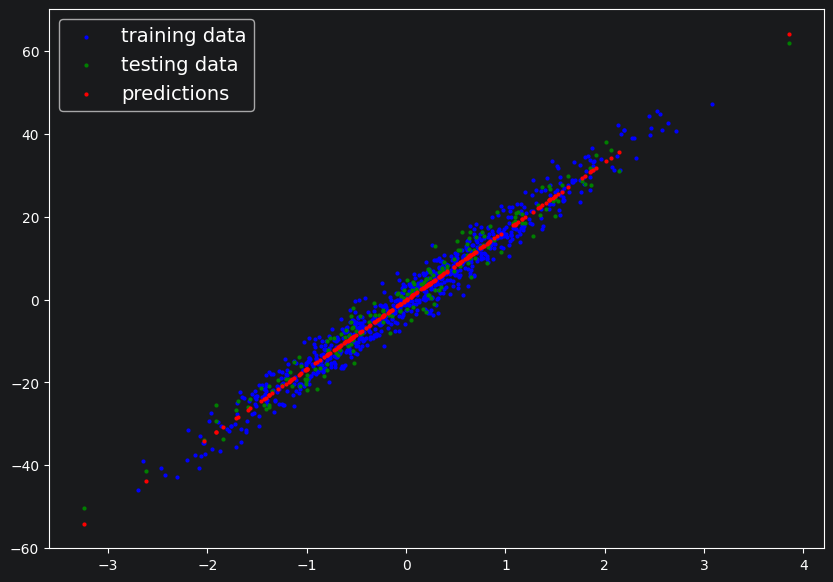

In [67]:
with torch.inference_mode():
    y_preds = model_2(X_test)

plot_predictions(X_train.cpu(), y_train.cpu(), X_test.cpu(), y_test.cpu(), predictions=y_preds.cpu())

# 6 Non Linearity

## 6.1 Recreating non-linear data (red and blue circles)



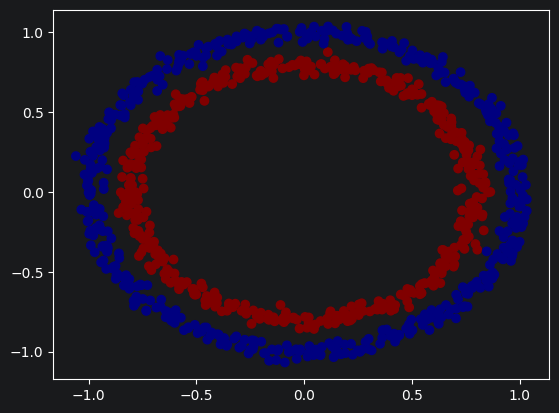

In [128]:
# Make and plot data
n_samples = 1000

# Create circles
X, y = make_circles(n_samples, noise=0.03, random_state=42)

plt.scatter(x=X[:, 0], y=X[:, 1], c=y, cmap=mpl.colormaps["jet"])


In [129]:
# Convert data to tensors and train split
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 6.2 Making non-Linear Model

In [130]:
# Build a model with non-linear activation functions
from torch import nn

class CircleModelV2(nn.Module):
    def __init__(self):
        super(CircleModelV2, self).__init__()
        self.layer_1 = nn.Linear(2, 10)
        self.layer_2 = nn.Linear(10, 10)
        self.layer_3 = nn.Linear(10, 1)
        self.relu = nn.ReLU() # non-linear activation function

    def forward(self, x):
        # Where should we put non-linear activation function ?
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
model_3


CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [134]:
# Training Non-Linear model

# Create loss function
loss_fn = nn.BCEWithLogitsLoss()
# Create optimizer
optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)
# Write training and eval loop for Model 3

torch.manual_seed(42)
torch.mps.manual_seed(42)
torch.cuda.manual_seed(42)

# Put data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
model_3.to(device)
epochs = 2000
for epoch in range(epochs):
    model_3.train()
    # Forward pass
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # Calculate loss
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_3.eval()
    with torch.inference_mode():
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}  Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.56818  Accuracy: 87.75% | Test Loss: 0.57378, Test Accuracy: 86.50%
Epoch: 100 | Loss: 0.48153  Accuracy: 93.50% | Test Loss: 0.49935, Test Accuracy: 90.50%
Epoch: 200 | Loss: 0.37056  Accuracy: 97.75% | Test Loss: 0.40595, Test Accuracy: 92.00%
Epoch: 300 | Loss: 0.25458  Accuracy: 99.00% | Test Loss: 0.30333, Test Accuracy: 96.50%
Epoch: 400 | Loss: 0.17180  Accuracy: 99.50% | Test Loss: 0.22108, Test Accuracy: 97.50%
Epoch: 500 | Loss: 0.12188  Accuracy: 99.62% | Test Loss: 0.16512, Test Accuracy: 99.00%
Epoch: 600 | Loss: 0.09123  Accuracy: 99.88% | Test Loss: 0.12741, Test Accuracy: 99.50%
Epoch: 700 | Loss: 0.07100  Accuracy: 99.88% | Test Loss: 0.10319, Test Accuracy: 99.50%
Epoch: 800 | Loss: 0.05773  Accuracy: 99.88% | Test Loss: 0.08672, Test Accuracy: 99.50%
Epoch: 900 | Loss: 0.04853  Accuracy: 99.88% | Test Loss: 0.07474, Test Accuracy: 99.50%
Epoch: 1000 | Loss: 0.04176  Accuracy: 99.88% | Test Loss: 0.06583, Test Accuracy: 100.00%
Epoch: 1100 | Loss: 0

In [135]:
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
print(y_preds[:10], y_test[:10])

tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='mps:0') tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='mps:0')


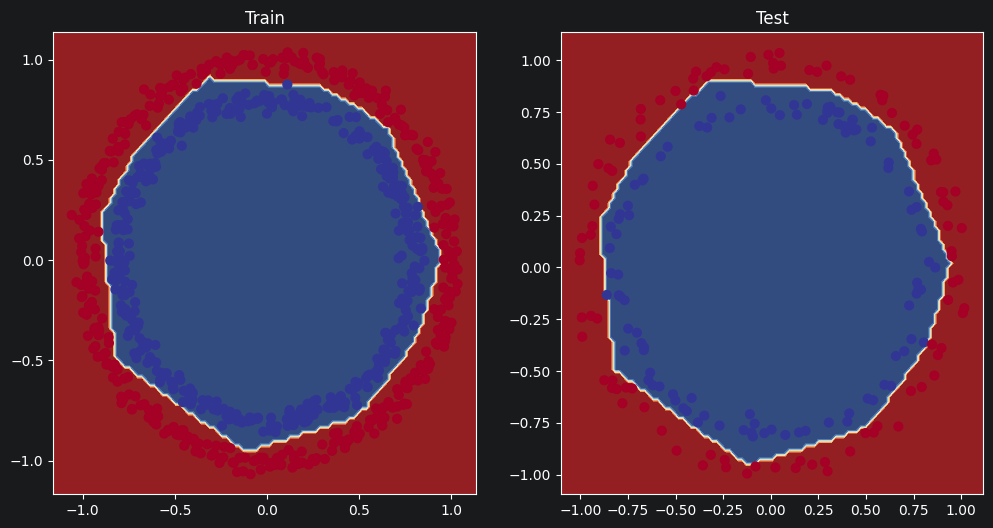

In [136]:


# Plot decision boundary
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

In [ ]:
# 7. Replicating non-linear activation functions

# Neural networks, rather than us telling the model what to learn, we give it the tools to discover patterns in data and it tries to figure out the patterns on its own.

# And these tools are linear and non-linear functions


In [139]:
# Create a tensor

A = torch.arange(-10, 10, 1, dtype=torch.float)

A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

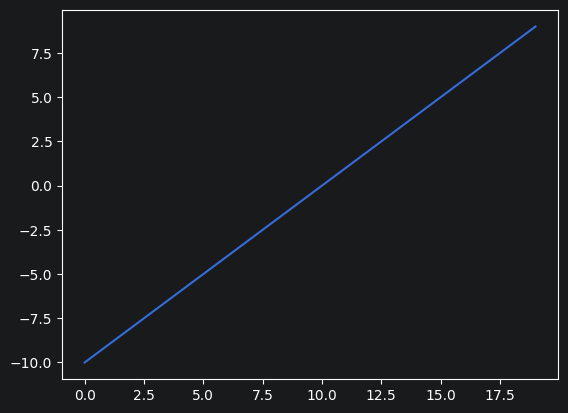

In [140]:
plt.plot(A)

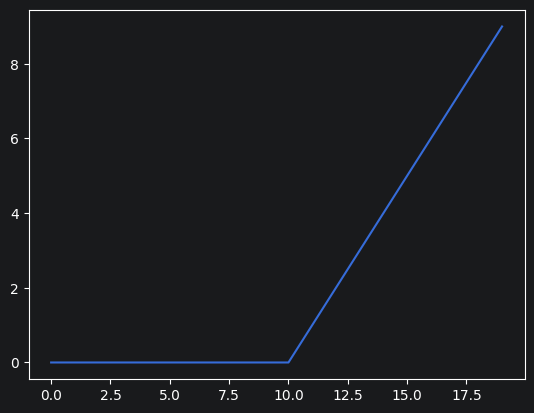

In [141]:
plt.plot(torch.relu(A))

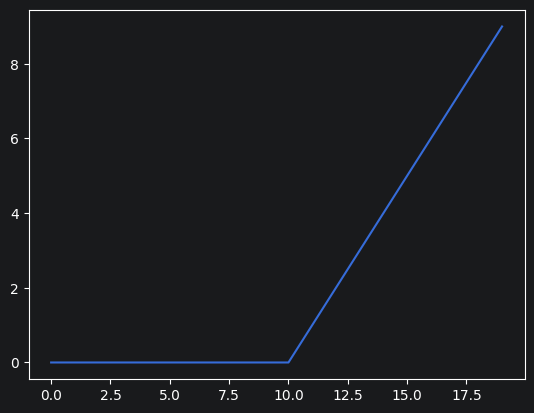

In [142]:
def relu(x: torch.Tensor) -> torch.Tensor:
    return torch.max(torch.tensor(0), x) # inputs must be tensors

plt.plot(relu(A))

In [144]:
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

In [145]:
def sigmoid(x: torch.Tensor) -> torch.Tensor:
    return torch.div(1, 1 + torch.exp(-x))

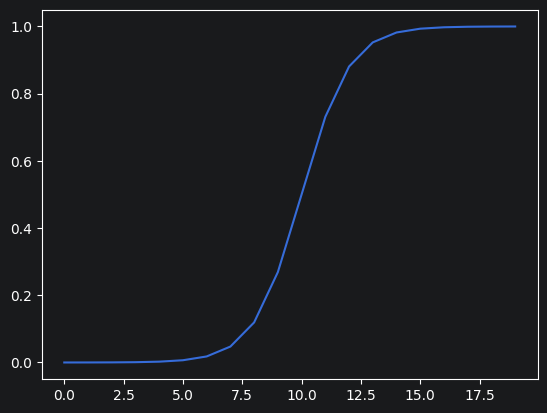

In [147]:
plt.plot(torch.sigmoid(A))

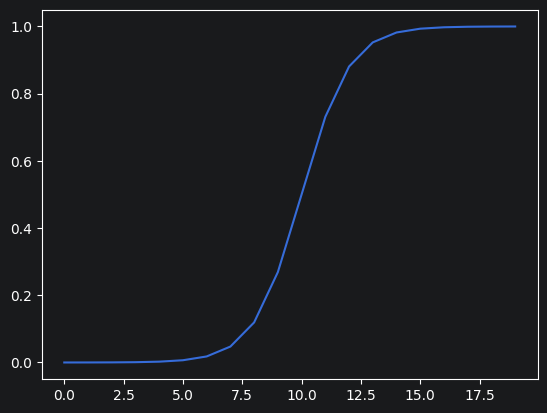

In [148]:
plt.plot(sigmoid(A))